## Estudio de Datos de la QBEE para cobertura terrestre
clases: Land,water,vegetation

Luego de definir las rutas, leemos los archivos y la forma de guardar cada anotacion.


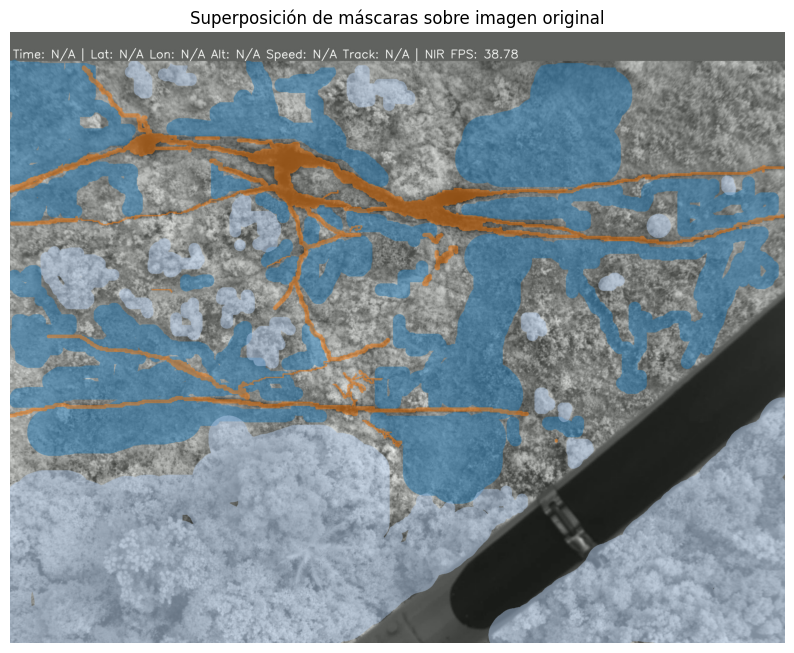

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

def visualizar_segmentacion(img_path, carpeta_mascaras, alpha=0.5):
    """
    Visualiza las máscaras binarias superpuestas sobre la imagen original.

    Parámetros:
        img_path (str): ruta de la imagen original
        carpeta_mascaras (str): carpeta con las máscaras binarias
        alpha (float): transparencia de la máscara superpuesta
    """
    # Leer imagen original
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Obtener lista de máscaras en la carpeta
    mascara_paths = sorted([
        os.path.join(carpeta_mascaras, f)
        for f in os.listdir(carpeta_mascaras)
        if f.lower().endswith(('.png', '.jpg', '.jpeg', '.tif', '.tiff'))
    ])

    if len(mascara_paths) == 0:
        raise ValueError("No se encontraron máscaras en la carpeta especificada.")

    n_masks = len(mascara_paths)

    # Generar colores distintos automáticamente
    cmap = plt.get_cmap('tab20')  # 20 colores distintos
    colores = [tuple((np.array(cmap(i)[:3]) * 255).astype(int)) for i in range(n_masks)]

    overlay = img_rgb.copy()

    for i, mask_path in enumerate(mascara_paths):
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        mask_bool = mask > 0  # True donde la máscara es blanca
        overlay[mask_bool] = (np.array(colores[i]) * alpha + overlay[mask_bool] * (1 - alpha)).astype(np.uint8)

    plt.figure(figsize=(10, 10))
    plt.imshow(overlay)
    plt.axis('off')
    plt.title("Superposición de máscaras sobre imagen original")
    plt.show()


# Uso corregido:
r_imagen = r"E:\MACHINE LEARNING\AVANZADO 1\VSFOLDER A1 PROYECT\OT-Detecci-n-de-objetos-VIS-NIR-ML-Colombia\Own_Data_Exploration\Land cover\frame_00028.png"
r_mascaras = r"E:\MACHINE LEARNING\AVANZADO 1\VSFOLDER A1 PROYECT\OT-Detecci-n-de-objetos-VIS-NIR-ML-Colombia\Own_Data_Exploration\Land cover\image label"

# Llamada correcta sin pasar 'colores'
visualizar_segmentacion(r_imagen, r_mascaras, alpha=0.5)


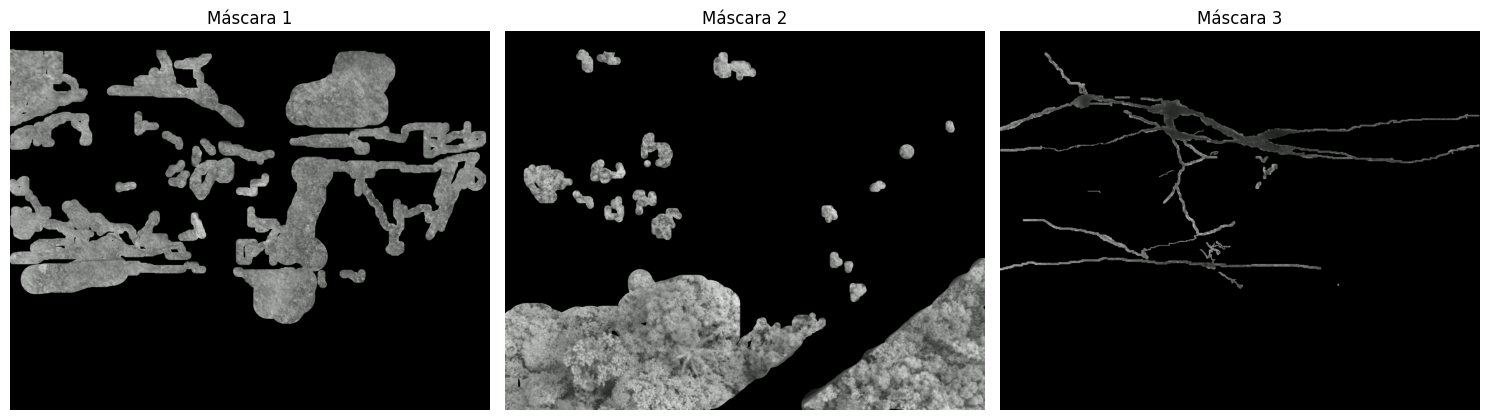

In [9]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

def mostrar_region_mascarada(img_path, carpeta_mascaras):
    """
    Muestra cada máscara aplicada sobre la imagen original, mostrando
    solo la región de la imagen original que corresponde a la máscara.

    Parámetros:
        img_path (str): ruta de la imagen original
        carpeta_mascaras (str): carpeta con máscaras binarias
    """
    # Leer imagen original
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Obtener lista de máscaras
    mascara_paths = sorted([
        os.path.join(carpeta_mascaras, f)
        for f in os.listdir(carpeta_mascaras)
        if f.lower().endswith(('.png', '.jpg', '.jpeg', '.tif', '.tiff'))
    ])

    n_masks = len(mascara_paths)
    if n_masks == 0:
        raise ValueError("No se encontraron máscaras en la carpeta especificada.")

    # Mostrar cada máscara aplicada
    plt.figure(figsize=(15, 5))
    for i, mask_path in enumerate(mascara_paths):
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        mask_bool = mask > 0

        # Crear imagen solo con la región de la máscara
        masked_img = np.zeros_like(img_rgb)
        masked_img[mask_bool] = img_rgb[mask_bool]

        plt.subplot(1, n_masks, i+1)
        plt.imshow(masked_img)
        plt.axis('off')
        plt.title(f"Máscara {i+1}")

    plt.tight_layout()
    plt.show()
mostrar_region_mascarada(r_imagen, r_mascaras)

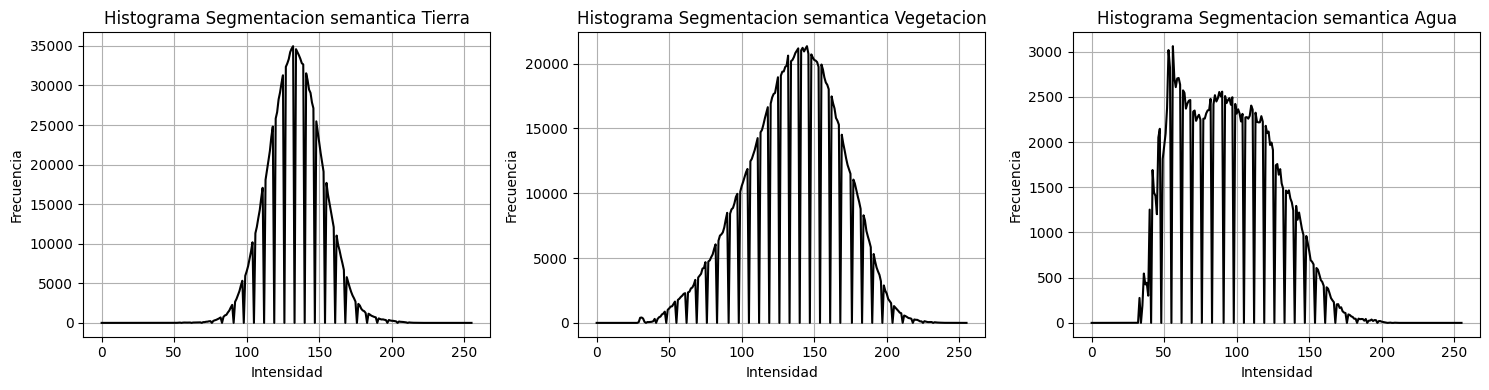

Mascara 1: Tierra, Mascara 2: Vegetacion, Mascara 3: Agua


In [3]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

def histograma_por_mascara(img_path, carpeta_mascaras, titulos=None):
    """
    Calcula y plotea histogramas de la imagen original para cada máscara,
    ignorando intensidades 0-3 y 253-255.

    Parámetros:
        img_path (str): ruta de la imagen original
        carpeta_mascaras (str): carpeta con máscaras binarias
        titulos (list de str, opcional): títulos para cada máscara
    """
    import cv2
    import numpy as np
    import matplotlib.pyplot as plt
    import os

    # Leer imagen original y convertir a gris
    img = cv2.imread(img_path)
    if len(img.shape) == 3:
        img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    else:
        img_gray = img.copy()

    # Obtener lista de máscaras
    mascara_paths = sorted([
        os.path.join(carpeta_mascaras, f)
        for f in os.listdir(carpeta_mascaras)
        if f.lower().endswith(('.png', '.jpg', '.jpeg', '.tif', '.tiff'))
    ])

    n_masks = len(mascara_paths)
    if n_masks == 0:
        raise ValueError("No se encontraron máscaras en la carpeta especificada.")

    # Si no hay títulos o no coinciden con la cantidad de máscaras, crear títulos por defecto
    if titulos is None or len(titulos) != n_masks:
        titulos = [f"Histograma Máscara {i+1}" for i in range(n_masks)]

    # Crear subplots
    fig, axes = plt.subplots(1, n_masks, figsize=(5*n_masks, 4))
    if n_masks == 1:
        axes = [axes]  # asegurar que sea iterable

    for i, mask_path in enumerate(mascara_paths):
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        mask_bool = mask > 0

        # Tomar solo los píxeles de la imagen original donde la máscara es blanca
        pixeles = img_gray[mask_bool]

        # Ignorar intensidades 0-3 y 253-255
        pixeles = pixeles[(pixeles > 3) & (pixeles < 253)]

        # Calcular histograma
        hist, bins = np.histogram(pixeles, bins=256, range=(0,255))

        # Plot
        axes[i].plot(hist, color='black')
        axes[i].set_title(titulos[i])
        axes[i].set_xlabel("Intensidad")
        axes[i].set_ylabel("Frecuencia")
        axes[i].grid(True)

    plt.tight_layout()
    plt.show()
titulos = ["Histograma Segmentacion semantica Tierra", "Histograma Segmentacion semantica Vegetacion", "Histograma Segmentacion semantica Agua"]
r_imagen = r"E:\MACHINE LEARNING\AVANZADO 1\VSFOLDER A1 PROYECT\OT-Detecci-n-de-objetos-VIS-NIR-ML-Colombia\Own_Data_Exploration\Land cover\frame_00028.png"
r_mascaras = r"E:\MACHINE LEARNING\AVANZADO 1\VSFOLDER A1 PROYECT\OT-Detecci-n-de-objetos-VIS-NIR-ML-Colombia\Own_Data_Exploration\Land cover\image label"

histograma_por_mascara(r_imagen, r_mascaras,titulos)
print("Mascara 1: Tierra,", "Mascara 2: Vegetacion,", "Mascara 3: Agua"  )

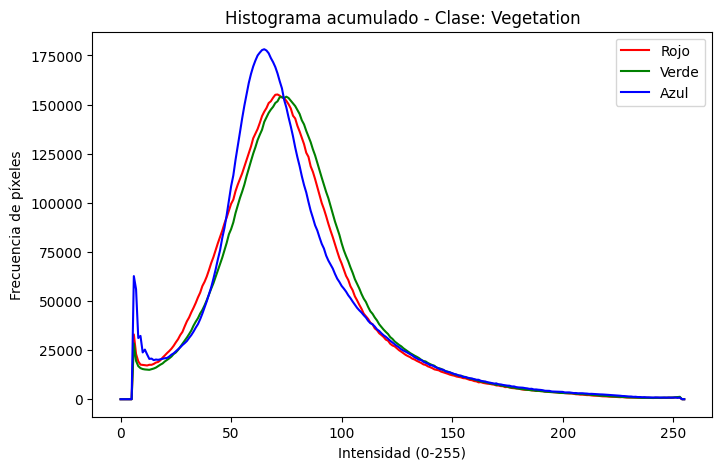
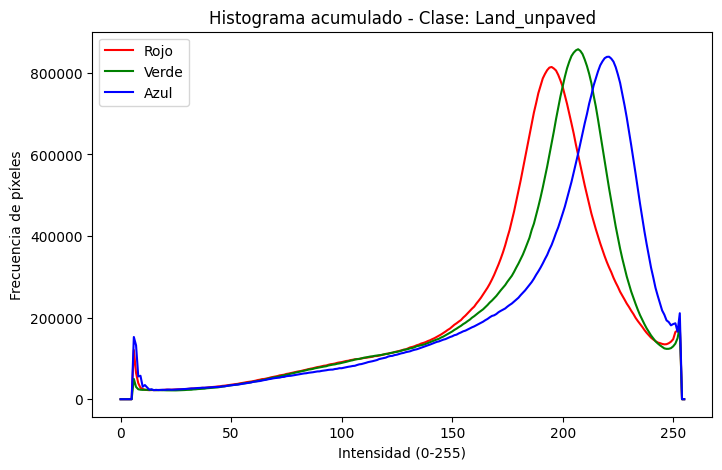

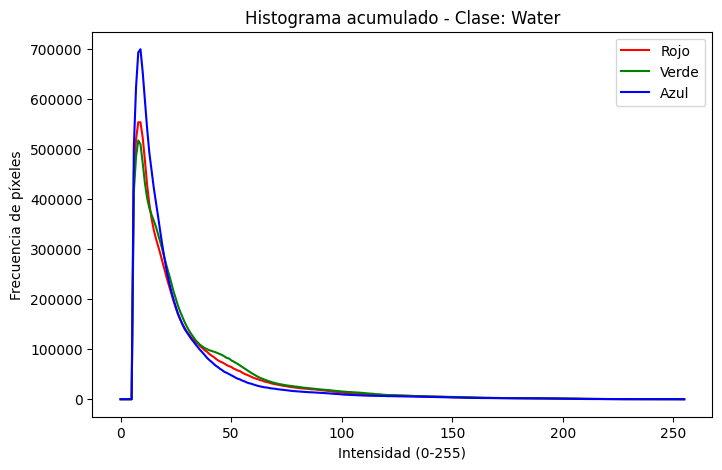